### Khám phá & Phân tích Dữ liệu (EDA) Chi tiết - TAWOS Dataset

Notebook này thực hiện **EDA (Exploratory Data Analysis)** chi tiết trên bộ dữ liệu **TAWOS (The Agile World of Software)** bao gồm các biểu đồ trực quan hóa bổ sung:

1. **Thống kê & Biểu đồ Đếm số Issue có Story Point**
2. **Biểu đồ Phân bố Missing Title / Description**
3. **Biểu đồ Phân bố Project (Issue per Project)**
4. **Phân bố Story Point**
5. **Thống kê Time Range**
6. **Thống kê Issue bị thay đổi Title/Description sau Estimation**
7. **Phân bố Số lượng Change Logs / Issue**
8. **Thời gian Change so với Estimation (Time Delta)**
9. **Các Case History cụ thể trích xuất từ Change Log**

---

### 1. Thư viện & Khởi tạo Kết nối CSDL

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị pandas & seaborn
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Kết nối đến CSDL SQLite
db_path = 'C:/tawos/tawos_eda.db'
conn = sqlite3.connect(db_path)
print("✅ Kết nối CSDL SQLite thành công!")

✅ Kết nối CSDL SQLite thành công!


### 2. Thống kê Số lượng Project & Issue Tổng quan

In [2]:
n_projects = pd.read_sql("SELECT COUNT(*) as total FROM Project;", conn).iloc[0]['total']
n_issues = pd.read_sql("SELECT COUNT(*) as total FROM Issue;", conn).iloc[0]['total']

print(f"📌 Tổng số Project: {n_projects}")
print(f"📌 Tổng số Issue: {n_issues:,}")

📌 Tổng số Project: 39
📌 Tổng số Issue: 458,232


### 3. Đếm & Biểu đồ Số lượng Issue có Story Point (`đếm số issue có Story Point`)

📌 THỐNG KÊ ISSUES CÓ STORY POINT:
   - Số Issue CÓ Story Point  : 63,011 (13.75%)
   - Số Issue KHÔNG Story Point: 395,221 (86.25%)
   - TỔNG SỐ ISSUES           : 458,232 (100.00%)


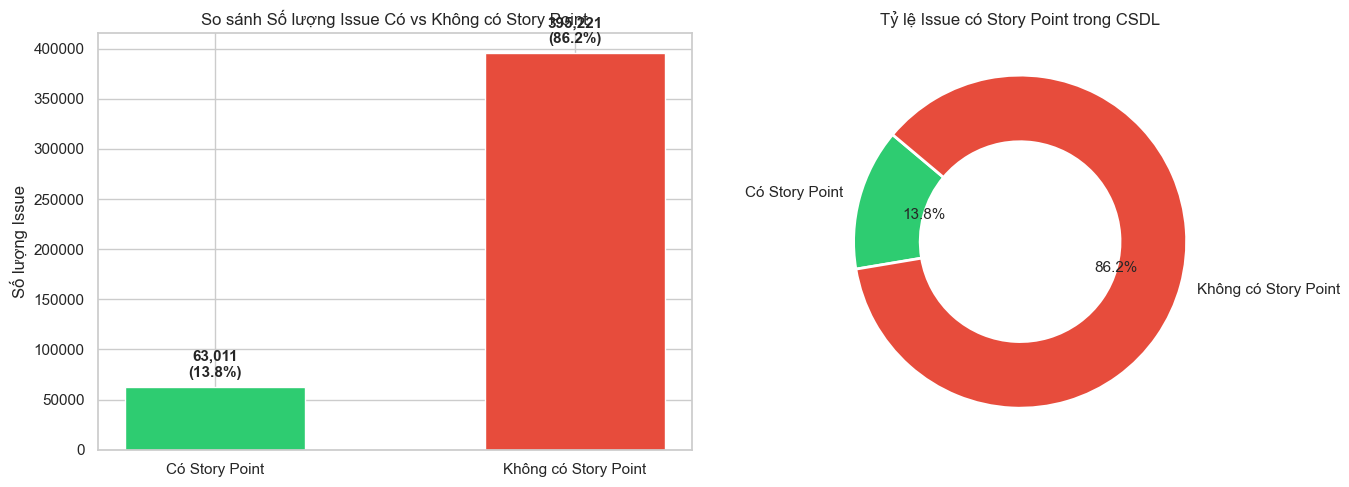

In [3]:
# Đếm số issue có Story Point
n_has_sp = pd.read_sql("SELECT COUNT(*) as count FROM Issue WHERE Story_Point IS NOT NULL AND Story_Point > 0;", conn).iloc[0]['count']
n_no_sp = n_issues - n_has_sp
pct_has_sp = (n_has_sp / n_issues) * 100
pct_no_sp = (n_no_sp / n_issues) * 100

print(f"=======================================================")
print(f"📌 THỐNG KÊ ISSUES CÓ STORY POINT:")
print(f"   - Số Issue CÓ Story Point  : {n_has_sp:,} ({pct_has_sp:.2f}%)")
print(f"   - Số Issue KHÔNG Story Point: {n_no_sp:,} ({pct_no_sp:.2f}%)")
print(f"   - TỔNG SỐ ISSUES           : {n_issues:,} (100.00%)")
print(f"=======================================================")

# Biểu đồ so sánh Issue có vs không có Story Point
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Biểu đồ cột (Bar plot)
categories = ['Có Story Point', 'Không có Story Point']
counts = [n_has_sp, n_no_sp]
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(categories, counts, color=colors, width=0.5)
axes[0].set_title('So sánh Số lượng Issue Có vs Không có Story Point')
axes[0].set_ylabel('Số lượng Issue')
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}\n({height/n_issues*100:.1f}%)',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold')

# 2. Biểu đồ tròn (Donut chart)
axes[1].pie(counts, labels=categories, autopct='%1.1f%%', startangle=140, 
            colors=colors, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2))
axes[1].set_title('Tỷ lệ Issue có Story Point trong CSDL')

plt.tight_layout()
plt.show()

### 4. Biểu đồ Phân bố Missing Title / Description (`missing title/description`)

,Both_Present,Missing_Desc_Only,Missing_Title_Only,Missing_Both
0,429104,29128,0,0


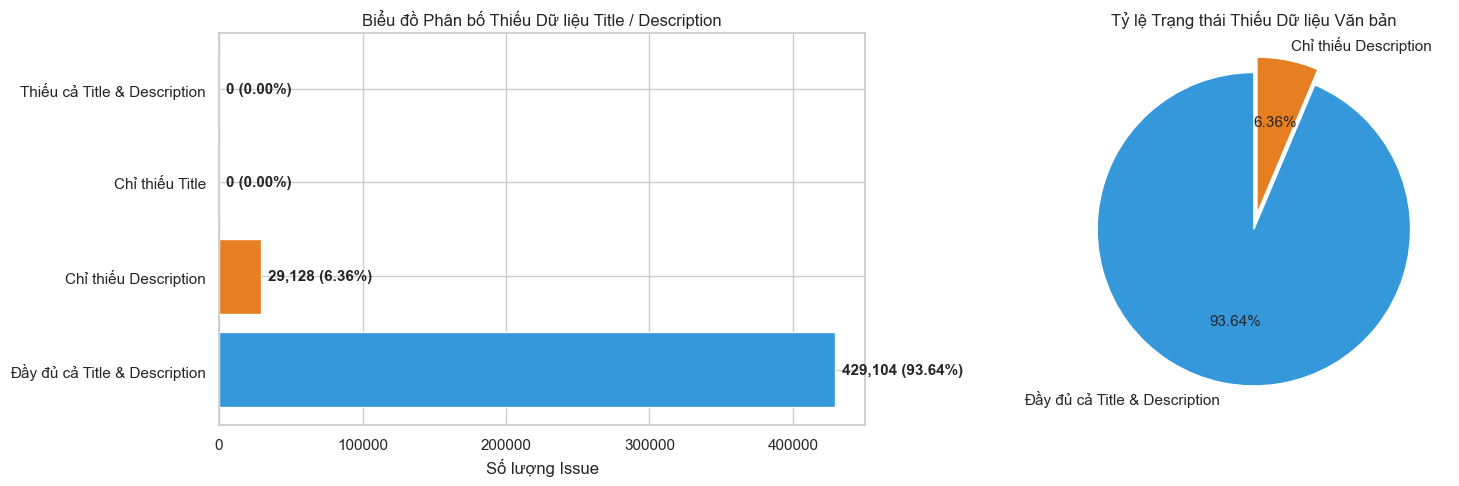

In [4]:
# Thống kê missing title / description
query_missing = '''
SELECT 
    SUM(CASE WHEN (Title IS NOT NULL AND TRIM(Title) != '') AND (Description IS NOT NULL AND TRIM(Description) != '') THEN 1 ELSE 0 END) as Both_Present,
    SUM(CASE WHEN (Title IS NOT NULL AND TRIM(Title) != '') AND (Description IS NULL OR TRIM(Description) = '') THEN 1 ELSE 0 END) as Missing_Desc_Only,
    SUM(CASE WHEN (Title IS NULL OR TRIM(Title) = '') AND (Description IS NOT NULL AND TRIM(Description) != '') THEN 1 ELSE 0 END) as Missing_Title_Only,
    SUM(CASE WHEN (Title IS NULL OR TRIM(Title) = '') AND (Description IS NULL OR TRIM(Description) = '') THEN 1 ELSE 0 END) as Missing_Both
FROM Issue;
'''
df_miss = pd.read_sql(query_missing, conn)
display(df_miss)

# Biểu đồ phân bố Missing Title / Description
labels = ['Đầy đủ cả Title & Description', 'Chỉ thiếu Description', 'Chỉ thiếu Title', 'Thiếu cả Title & Description']
val_counts = [df_miss['Both_Present'].iloc[0], df_miss['Missing_Desc_Only'].iloc[0], 
              df_miss['Missing_Title_Only'].iloc[0], df_miss['Missing_Both'].iloc[0]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ cột thể hiện phân bố dữ liệu thiếu
colors_miss = ['#3498db', '#e67e22', '#e74c3c', '#9b59b6']
bars_miss = axes[0].barh(labels, val_counts, color=colors_miss)
axes[0].set_title('Biểu đồ Phân bố Thiếu Dữ liệu Title / Description')
axes[0].set_xlabel('Số lượng Issue')
for bar in bars_miss:
    width = bar.get_width()
    axes[0].annotate(f'{int(width):,} ({width/n_issues*100:.2f}%)',
                     xy=(width, bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     ha='left', va='center', fontweight='bold')

# Biểu đồ hình tròn tỷ lệ
non_zero_labels = [l for l, v in zip(labels, val_counts) if v > 0]
non_zero_vals = [v for v in val_counts if v > 0]
non_zero_colors = [c for c, v in zip(colors_miss, val_counts) if v > 0]

axes[1].pie(non_zero_vals, labels=non_zero_labels, autopct='%1.2f%%', startangle=90,
            colors=non_zero_colors, explode=[0, 0.1] if len(non_zero_vals) == 2 else None)
axes[1].set_title('Tỷ lệ Trạng thái Thiếu Dữ liệu Văn bản')

plt.tight_layout()
plt.show()

### 5. Biểu đồ Phân bố Project (`phân bố project` / `issue/project`)

--- Thống kê Mô tả Phân bố Issue theo Project ---


count       39.000000
mean     11749.538462
std      15418.919711
min        313.000000
25%       1525.000000
50%       5533.000000
75%      13272.000000
max      66741.000000
Name: Issue_Count, dtype: float64


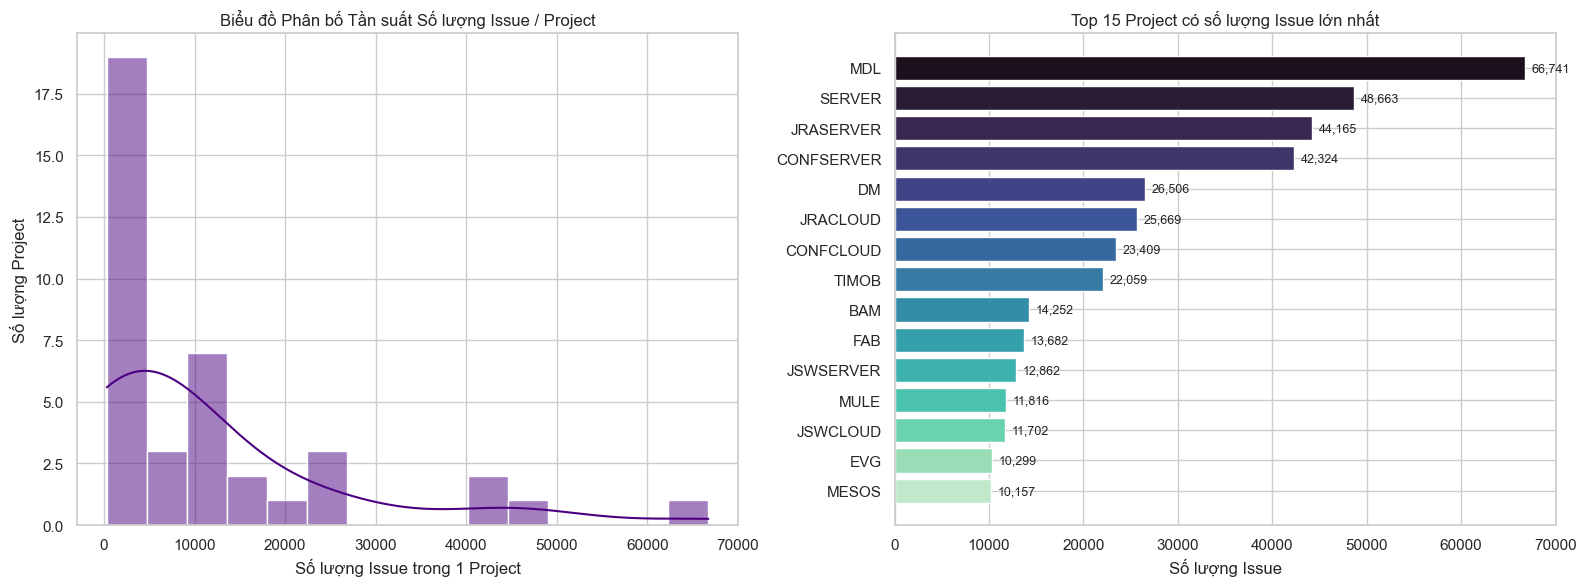

In [5]:
# Lấy số lượng Issue theo từng Project
query_proj_dist = '''
SELECT p.Project_Key, p.Name AS Project_Name, r.Name AS Repository_Name, COUNT(i.ID) as Issue_Count
FROM Project p
LEFT JOIN Issue i ON p.ID = i.Project_ID
LEFT JOIN Repository r ON p.Repository_ID = r.ID
GROUP BY p.ID, p.Project_Key, p.Name, r.Name
ORDER BY Issue_Count DESC;
'''
df_proj_dist = pd.read_sql(query_proj_dist, conn)

print("--- Thống kê Mô tả Phân bố Issue theo Project ---")
display(df_proj_dist['Issue_Count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ phân bố (Histogram & KDE) thể hiện số lượng issue trên mỗi project
sns.histplot(df_proj_dist['Issue_Count'], kde=True, ax=axes[0], color='indigo', bins=15)
axes[0].set_title('Biểu đồ Phân bố Tần suất Số lượng Issue / Project')
axes[0].set_xlabel('Số lượng Issue trong 1 Project')
axes[0].set_ylabel('Số lượng Project')

# 2. Top 15 Project có số lượng Issue nhiều nhất
top15 = df_proj_dist.head(15)
bars_p = axes[1].barh(top15['Project_Key'], top15['Issue_Count'], color=sns.color_palette('mako', 15))
axes[1].set_title('Top 15 Project có số lượng Issue lớn nhất')
axes[1].set_xlabel('Số lượng Issue')
axes[1].invert_yaxis()  # Đảo thứ tự để lớn nhất ở trên cùng
for bar in bars_p:
    width = bar.get_width()
    axes[1].annotate(f'{int(width):,}',
                     xy=(width, bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6. Phân bố điểm Story Point (`phân bố Story Point`)

--- Thống kê mô tả Story Point ---


count    6.301100e+04
mean     4.294292e+02
std      1.064063e+05
min      1.000000e-04
25%      1.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      2.671011e+07
Name: Story_Point, dtype: float64


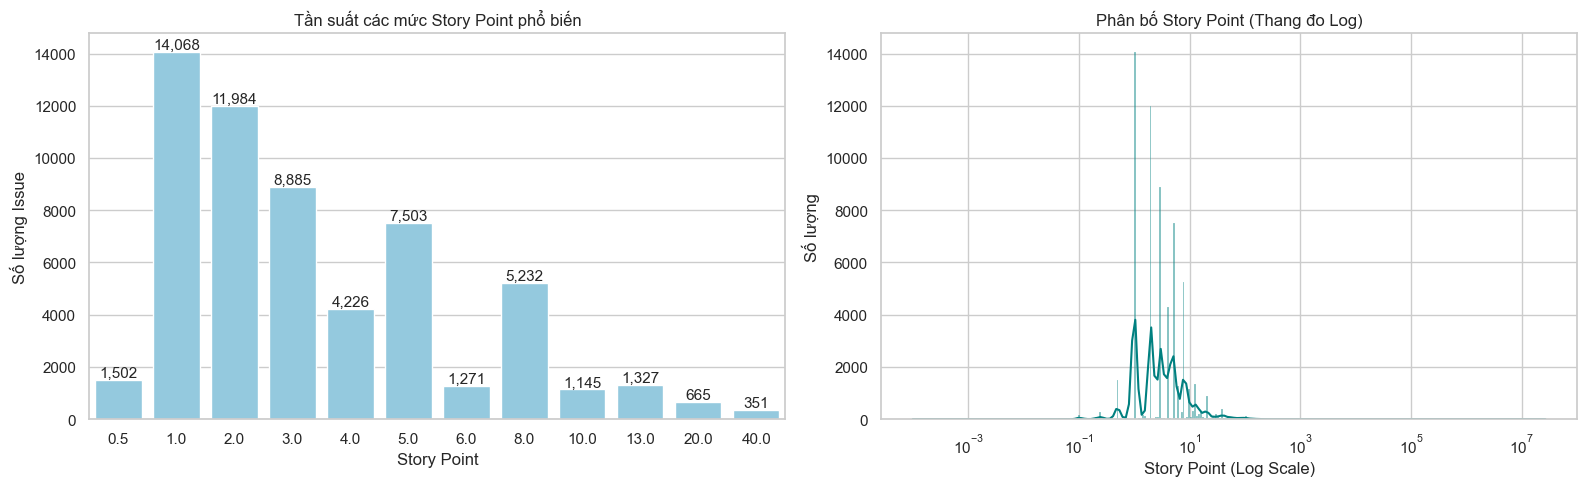

In [6]:
# Phân bố Story Point
df_sp = pd.read_sql("SELECT Story_Point FROM Issue WHERE Story_Point IS NOT NULL AND Story_Point > 0;", conn)

print("--- Thống kê mô tả Story Point ---")
display(df_sp['Story_Point'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ đếm các mức Story Point phổ biến
sp_counts = df_sp['Story_Point'].value_counts().head(12).sort_index()
sns.barplot(x=sp_counts.index.astype(str), y=sp_counts.values, ax=axes[0], color='skyblue')
axes[0].set_title('Tần suất các mức Story Point phổ biến')
axes[0].set_xlabel('Story Point')
axes[0].set_ylabel('Số lượng Issue')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Biểu đồ phân bố (Log Scale)
sns.histplot(df_sp['Story_Point'], log_scale=True, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Phân bố Story Point (Thang đo Log)')
axes[1].set_xlabel('Story Point (Log Scale)')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

### 7. Khoảng thời gian Dữ liệu (`time range`)

In [7]:
query_tr = '''
SELECT 
    MIN(Creation_Date) as Earliest_Created_Date,
    MAX(Creation_Date) as Latest_Created_Date,
    MIN(Resolution_Date) as Earliest_Resolution_Date,
    MAX(Resolution_Date) as Latest_Resolution_Date
FROM Issue;
'''
df_tr = pd.read_sql(query_tr, conn)
print("📌 Khoảng thời gian của toàn bộ dữ liệu (Time Range):")
display(df_tr)

📌 Khoảng thời gian của toàn bộ dữ liệu (Time Range):


,Earliest_Created_Date,Latest_Created_Date,Earliest_Resolution_Date,Latest_Resolution_Date
0,2002-02-08 04:45:00,2020-10-23 22:13:07,2004-02-12 23:48:28,2020-10-23 04:53:21


### 8. Thống kê Issue có Title/Description thay đổi sau Estimation (`issue có title/description changed after estimation`)

📌 Thống kê Issue bị thay đổi Title / Description sau khi Estimation:


,Estimated_Issues,Title_Changed,Description_Changed,Either_Text_Changed,Pct_Title_Changed,Pct_Desc_Changed,Pct_Either_Changed
0,63011,11969,0,11969,18.995096,0.0,18.995096


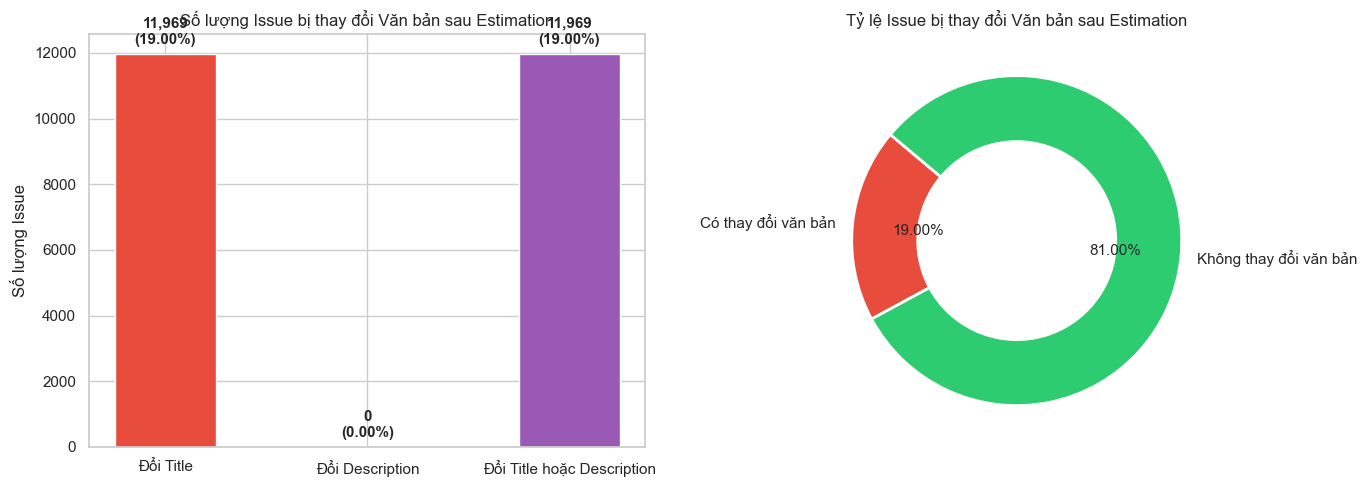

In [8]:
query_changed_after = """
SELECT 
    COUNT(*) as Estimated_Issues,
    SUM(CASE WHEN Title_Changed_After_Estimation = 1 THEN 1 ELSE 0 END) as Title_Changed,
    SUM(CASE WHEN Description_Changed_After_Estimation = 1 THEN 1 ELSE 0 END) as Description_Changed,
    SUM(CASE WHEN Title_Changed_After_Estimation = 1 OR Description_Changed_After_Estimation = 1 THEN 1 ELSE 0 END) as Either_Text_Changed
FROM Issue
WHERE Story_Point IS NOT NULL AND Story_Point > 0;
"""
df_changed_after = pd.read_sql(query_changed_after, conn)
df_changed_after['Pct_Title_Changed'] = (df_changed_after['Title_Changed'] / df_changed_after['Estimated_Issues']) * 100
df_changed_after['Pct_Desc_Changed'] = (df_changed_after['Description_Changed'] / df_changed_after['Estimated_Issues']) * 100
df_changed_after['Pct_Either_Changed'] = (df_changed_after['Either_Text_Changed'] / df_changed_after['Estimated_Issues']) * 100

print("📌 Thống kê Issue bị thay đổi Title / Description sau khi Estimation:")
display(df_changed_after)

# Biểu đồ so sánh số lượng & tỷ lệ Issue bị thay đổi Title/Description sau Estimation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Đổi Title', 'Đổi Description', 'Đổi Title hoặc Description']
counts = [
    df_changed_after['Title_Changed'].iloc[0],
    df_changed_after['Description_Changed'].iloc[0],
    df_changed_after['Either_Text_Changed'].iloc[0]
]
pcts = [
    df_changed_after['Pct_Title_Changed'].iloc[0],
    df_changed_after['Pct_Desc_Changed'].iloc[0],
    df_changed_after['Pct_Either_Changed'].iloc[0]
]
colors = ['#e74c3c', '#3498db', '#9b59b6']

# 1. Biểu đồ cột thể hiện số lượng
bars = axes[0].bar(categories, counts, color=colors, width=0.5)
axes[0].set_title('Số lượng Issue bị thay đổi Văn bản sau Estimation')
axes[0].set_ylabel('Số lượng Issue')
for bar, pct in zip(bars, pcts):
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}\n({pct:.2f}%)',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold')

# 2. Biểu đồ tròn thể hiện tỷ lệ so với tổng Estimated Issues
total_est = df_changed_after['Estimated_Issues'].iloc[0]
no_change = total_est - df_changed_after['Either_Text_Changed'].iloc[0]
pie_labels = ['Có thay đổi văn bản', 'Không thay đổi văn bản']
pie_counts = [df_changed_after['Either_Text_Changed'].iloc[0], no_change]
pie_colors = ['#e74c3c', '#2ecc71']

axes[1].pie(pie_counts, labels=pie_labels, autopct='%1.2f%%', startangle=140,
            colors=pie_colors, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2))
axes[1].set_title('Tỷ lệ Issue bị thay đổi Văn bản sau Estimation')

plt.tight_layout()
plt.show()

### 9. Phân bố Số lượng Change Logs / Issue (`số change logs/issue`)

Số lượng Issue có ít nhất 1 Change Log: 447,356
--- Thống kê mô tả số Change Logs per Issue ---


count    447356.000000
mean         20.374382
std          25.865719
min           1.000000
25%           9.000000
50%          15.000000
75%          25.000000
max        3892.000000
Name: Num_Change_Logs, dtype: float64


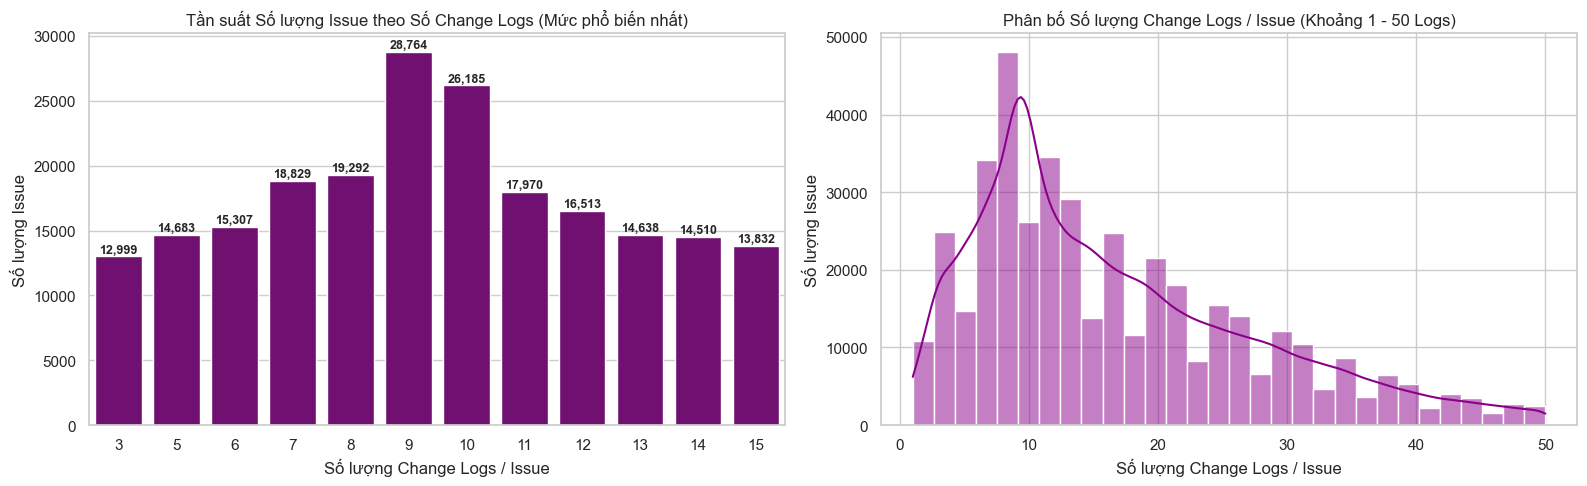

In [9]:
query_cl_per_issue = """
SELECT Issue_ID, COUNT(*) as Num_Change_Logs
FROM Change_Log
GROUP BY Issue_ID;
"""
df_cl_counts = pd.read_sql(query_cl_per_issue, conn)

print(f"Số lượng Issue có ít nhất 1 Change Log: {len(df_cl_counts):,}")
print("--- Thống kê mô tả số Change Logs per Issue ---")
display(df_cl_counts['Num_Change_Logs'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Biểu đồ cột hiển thị tần suất số lượng Change Logs theo các mức phổ biến (1-12 logs)
cl_grouped = df_cl_counts['Num_Change_Logs'].value_counts().head(12).sort_index()
sns.barplot(x=cl_grouped.index.astype(str), y=cl_grouped.values, ax=axes[0], color='purple')
axes[0].set_title('Tần suất Số lượng Issue theo Số Change Logs (Mức phổ biến nhất)')
axes[0].set_xlabel('Số lượng Change Logs / Issue')
axes[0].set_ylabel('Số lượng Issue')
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{int(height):,}', (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# 2. Biểu đồ Phân bố Tổng quát theo Số lượng Issue (Khoảng 1 - 50 logs)
df_cl_filtered = df_cl_counts[df_cl_counts['Num_Change_Logs'] <= 50]
sns.histplot(df_cl_filtered['Num_Change_Logs'], bins=30, kde=True, ax=axes[1], color='darkmagenta')
axes[1].set_title('Phân bố Số lượng Change Logs / Issue (Khoảng 1 - 50 Logs)')
axes[1].set_xlabel('Số lượng Change Logs / Issue')
axes[1].set_ylabel('Số lượng Issue')

plt.tight_layout()
plt.show()

### 10. Thời gian thay đổi so với Estimation (`thời gian change so với estimation`)

📌 Tổng số lượt thay đổi Title/Description diễn ra SAU Estimation: 51,485
--- Thống kê khoảng cách thời gian (Time Delta) ---


,Time_Delta_Hours,Time_Delta_Days
count,51485.000000,51485.000000
mean,1736.835636,72.368152
std,5375.257587,223.969066
min,0.000000,0.000000
25%,0.379722,0.015822
50%,55.295556,2.303981
75%,837.170833,34.882118
max,110889.052500,4620.377188


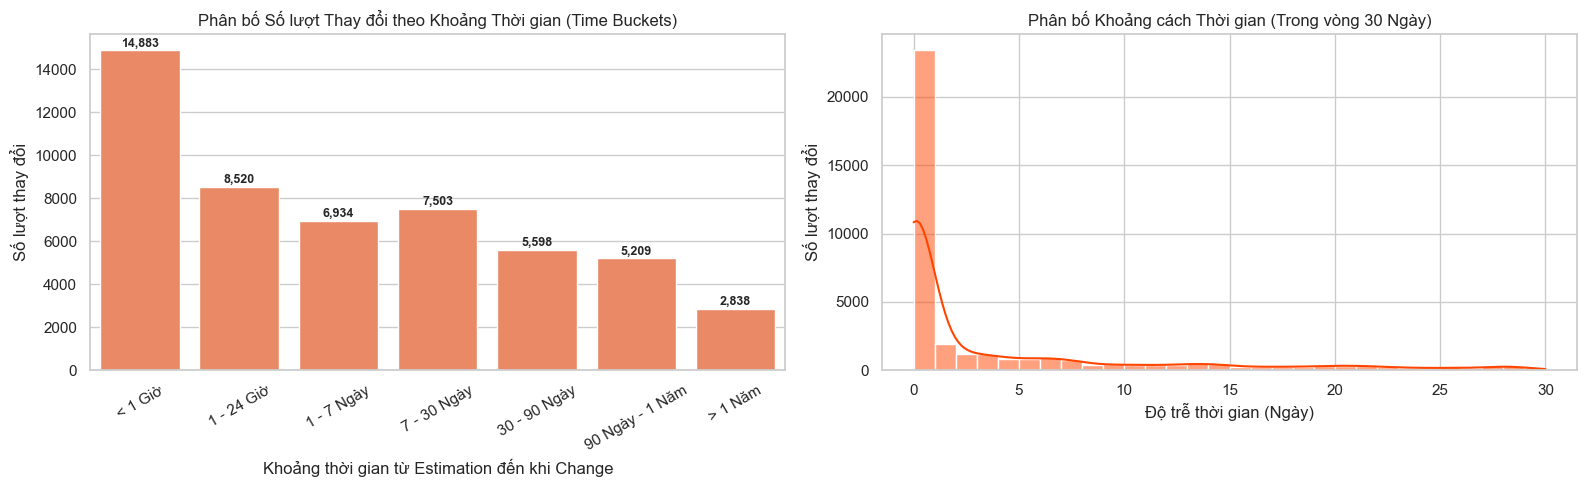

In [10]:
query_time_delta = """
SELECT 
    i.ID as Issue_ID, 
    i.Issue_Key, 
    i.Estimation_Date, 
    c.Field, 
    c.Creation_Date as Change_Date,
    (julianday(c.Creation_Date) - julianday(i.Estimation_Date)) as Time_Delta_Days,
    (julianday(c.Creation_Date) - julianday(i.Estimation_Date)) * 24.0 as Time_Delta_Hours
FROM Issue i
JOIN Change_Log c ON i.ID = c.Issue_ID
WHERE i.Story_Point IS NOT NULL 
  AND i.Estimation_Date IS NOT NULL
  AND LOWER(c.Field) IN ('summary', 'description', 'title')
  AND c.Creation_Date >= i.Estimation_Date;
"""
df_delta = pd.read_sql(query_time_delta, conn)
print(f"📌 Tổng số lượt thay đổi Title/Description diễn ra SAU Estimation: {len(df_delta):,}")
print("--- Thống kê khoảng cách thời gian (Time Delta) ---")
display(df_delta[['Time_Delta_Hours', 'Time_Delta_Days']].describe())

# Phân nhóm khoảng thời gian trễ (Time Delta)
bins = [-0.001, 1/24, 1, 7, 30, 90, 365, 10000]
labels_range = ['< 1 Giờ', '1 - 24 Giờ', '1 - 7 Ngày', '7 - 30 Ngày', '30 - 90 Ngày', '90 Ngày - 1 Năm', '> 1 Năm']
df_delta['Time_Bucket'] = pd.cut(df_delta['Time_Delta_Days'], bins=bins, labels=labels_range)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Biểu đồ cột theo nhóm khoảng thời gian (Count per Time Bucket)
bucket_counts = df_delta['Time_Bucket'].value_counts()[labels_range]
sns.barplot(x=bucket_counts.index, y=bucket_counts.values, ax=axes[0], color='coral')
axes[0].set_title('Phân bố Số lượt Thay đổi theo Khoảng Thời gian (Time Buckets)')
axes[0].set_xlabel('Khoảng thời gian từ Estimation đến khi Change')
axes[0].set_ylabel('Số lượt thay đổi')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height):,}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# 2. Biểu đồ Phân bố Histogram trong khoảng 0 - 30 ngày
df_delta_sub = df_delta[df_delta['Time_Delta_Days'] <= 30]
sns.histplot(df_delta_sub['Time_Delta_Days'], bins=30, kde=True, ax=axes[1], color='orangered')
axes[1].set_title('Phân bố Khoảng cách Thời gian (Trong vòng 30 Ngày)')
axes[1].set_xlabel('Độ trễ thời gian (Ngày)')
axes[1].set_ylabel('Số lượt thay đổi')

plt.tight_layout()
plt.show()

### 11. Các Case History cụ thể trích xuất từ Change Log (`một vài case history cụ thể`)

In [11]:
# Chọn 3 Issue tiêu biểu có điểm Story Point và bị đổi Title / Description sau Estimation
query_sample_cases = '''
SELECT i.ID, i.Issue_Key, i.Story_Point, i.Creation_Date, i.Estimation_Date, i.Title
FROM Issue i
WHERE i.Story_Point IS NOT NULL 
  AND (i.Title_Changed_After_Estimation = 1 OR i.Description_Changed_After_Estimation = 1)
  AND i.Estimation_Date IS NOT NULL
ORDER BY i.ID ASC
LIMIT 3;
'''
df_samples = pd.read_sql(query_sample_cases, conn)

for idx, row in df_samples.iterrows():
    issue_id = row['ID']
    print('=' * 60)
    print(f"📌 CASE HISTORY: {row['Issue_Key']} (Issue ID: {issue_id})")
    print(f"   - Tiêu đề hiện tại: {row['Title']}")
    print(f"   - Ngày tạo: {row['Creation_Date']}")
    print(f"   - Ngày Estimation: {row['Estimation_Date']} | Story Point: {row['Story_Point']}")
    print(f"   - Lịch sử Change Logs đầy đủ:")
    
    query_history = f'''
    SELECT ID, Field, From_String, To_String, Creation_Date, Author_ID
    FROM Change_Log
    WHERE Issue_ID = {issue_id}
    ORDER BY Creation_Date ASC;
    '''
    df_hist = pd.read_sql(query_history, conn)
    display(df_hist)

📌 CASE HISTORY: XD-3765 (Issue ID: 68)
   - Tiêu đề hiện tại: \"Fix stream failover \"
   - Ngày tạo: 2017-03-21 16:54:44
   - Ngày Estimation: 2017-03-21 16:54:44 | Story Point: 8.0
   - Lịch sử Change Logs đầy đủ:
📌 CASE HISTORY: XD-3754 (Issue ID: 79)
   - Tiêu đề hiện tại: \"Composed Module Child Module Validated Too Early\"
   - Ngày tạo: 2016-05-02 23:09:05
   - Ngày Estimation: 2016-05-02 22:09:05 | Story Point: 5.0
   - Lịch sử Change Logs đầy đủ:
📌 CASE HISTORY: XD-3750 (Issue ID: 83)
   - Tiêu đề hiện tại: \"Cant completely remove custom module after putting properties in /config/modules/job/xx/xx.properties\"
   - Ngày tạo: 2016-02-29 10:00:19
   - Ngày Estimation: 2016-02-29 10:00:19 | Story Point: 1.0
   - Lịch sử Change Logs đầy đủ:


,ID,Field,From_String,To_String,Creation_Date,Author_ID
0,6,Fix Version,NaN,1.3.2,2017-03-21 16:54:56,72
1,7,resolution,NaN,Complete,2017-03-21 16:55:23,72
2,8,status,To Do,Done,2017-03-21 16:55:23,72
3,9,summary,Fix stream failover on YARN,Fix stream failover,2017-03-22 18:27:01,72


,ID,Field,From_String,To_String,Creation_Date,Author_ID
0,43,summary,Composed Module Validated Too Early,Composed Module Child Module Validated Too Early,2016-05-02 23:14:39,82
1,44,Fix Version,NaN,1.3.2,2016-05-02 23:16:59,78
2,45,Fix Version,NaN,1.3.3,2016-12-23 14:47:40,72
3,46,Fix Version,1.3.2,NaN,2016-12-23 14:47:40,72


,ID,Field,From_String,To_String,Creation_Date,Author_ID
0,50,summary,Can completely remove module after putting properties in /modules/job/xx/xx.properties,Can completely remove custom module after putting properties in /modules/job/xx/xx.properties,2016-02-29 10:00:55,86
1,51,issuetype,Story,Bug,2016-02-29 10:01:41,86
2,52,summary,Can completely remove custom module after putting properties in /modules/job/xx/xx.properties,Can completely remove custom module after putting properties in /config/modules/job/xx/xx.properties,2016-02-29 10:03:15,86
3,53,summary,Can completely remove custom module after putting properties in /config/modules/job/xx/xx.properties,Cant completely remove custom module after putting properties in /config/modules/job/xx/xx.properties,2016-03-13 10:24:16,86
